# Viewpoint Filter Builder

Interactively choose a detection subset from preliminary Laplacian EV thresholds, then save a minimal JSON filter artifact containing only detection IDs and metadata.

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import time
from collections import Counter
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from src.analysis.viewpoint_filters import save_viewpoint_filter
from src.codebook.gmm_trainer import load_gmm_model
from src.config.config import MainConfig
from src.data.annotation_loader import load_annotations
from src.data.preprocessed_dataset import PreprocessedDataset
from src.evaluation import COARSE_MAP, coarse_viewpoint, load_or_compute_matching
from src.features.fisher_vector import build_block_mask, normalize_fvs
from src.laplacian import build_knn_graph, normalized_laplacian, smallest_eigenvectors

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
# ============================================================
# Settings
# ============================================================

CONFIG_PATH = Path('../config_seals.yaml')

# FV components should match viewpoint_classification.ipynb.
USE_WEIGHT = True
USE_MEAN = True
USE_VAR = True
MAX_PCA_DIM = None

# Preliminary graph used only to choose the filter.
KNN_K = 10
N_EIG = 6

# EV pair for the static scatterplot cell below. EV0 is the constant mode.
EV_X = 1
EV_Y = 2

# Artifact name. Saved to config.output_root / 'viewpoint_filters' / f'{FILTER_NAME}.json'.
FILTER_NAME = 'hands_filter'

In [3]:
# ============================================================
# Load config, dataset, raw FVs, and GT matching
# ============================================================

config = MainConfig.from_yaml(CONFIG_PATH)
dataset = PreprocessedDataset(config.output_root)
coco_loader = load_annotations(config)

raw_pkl_path = config.output_root / 'weight_fisher_vectors_raw.pkl'
print(f'Loading raw weight FVs from {raw_pkl_path}')
with open(raw_pkl_path, 'rb') as f:
    raw_data = pickle.load(f)
all_det_ids = raw_data['det_ids']
all_fvs_raw = raw_data['fvs_raw']
del raw_data

gmm, _ = load_gmm_model(config.gmm_model_path)
K = gmm.n_components
D = gmm.means_.shape[1]
del gmm

fv_mask = build_block_mask(K, D, USE_WEIGHT, USE_MEAN, USE_VAR, MAX_PCA_DIM)
all_fvs_norm = normalize_fvs(all_fvs_raw, fv_mask)
del all_fvs_raw

matched = load_or_compute_matching(
    dataset, coco_loader, config.output_root,
    target_size=config.active_resize_size,
    patch_size=config.active_patch_size,
    category_names=config.matching_categories,
    min_overlap_fraction=0.5,
)
print(f'Matched: {len(matched)} detections')

det_to_viewpoint = {m.detection_id: m.gt_annotation.viewpoint for m in matched}
det_id_to_idx = {d: i for i, d in enumerate(all_det_ids)}
print(f'Raw FVs: {len(all_det_ids)} detections, shape={all_fvs_norm.shape}')

Loading raw weight FVs from /scratch/project_2001382/alex/semantic-matching-output/seal/weight_fisher_vectors_raw.pkl
Loaded 2858 matching results from cache (/scratch/project_2001382/alex/semantic-matching-output/seal/matching/gt_matching.json)
Matched: 2858 detections
Raw FVs: 3512 detections, shape=(3512, 32832)


In [4]:
# ============================================================
# Build valid-viewpoint subset
# ============================================================

valid_dets = []
valid_vps = []
valid_raw_vps = []
for det_id in all_det_ids:
    raw_vp = det_to_viewpoint.get(det_id, 'unknown')
    if raw_vp in ('ignore', 'unknown'):
        continue
    coarse = COARSE_MAP.get(raw_vp)
    if coarse is None:
        continue
    valid_dets.append(det_id)
    valid_vps.append(coarse)
    valid_raw_vps.append(raw_vp)

valid_fv_idx = np.array([det_id_to_idx[d] for d in valid_dets])
valid_fvs = all_fvs_norm[valid_fv_idx]
valid_vps = np.array(valid_vps)
valid_raw_vps = np.array(valid_raw_vps)
del all_fvs_norm

print(f'Valid detections: {len(valid_dets)}')
for vp, cnt in Counter(valid_vps).most_common():
    print(f'  {vp:>12}: {cnt:5d}')

Valid detections: 2858
         right:  1496
          left:  1362


In [5]:
# ============================================================
# Compute preliminary Laplacian EVs for filter selection
# ============================================================

print(f'Building {KNN_K}-NN graph on {valid_fvs.shape[0]} FVs...')
t0 = time.time()
A, degrees = build_knn_graph(valid_fvs, k=KNN_K)
L_sym = normalized_laplacian(A, degrees)
print(f'  Graph + Laplacian built in {time.time() - t0:.1f}s')

print(f'Computing {N_EIG} smallest Laplacian eigenvectors...')
eigenvalues, eigenvectors = smallest_eigenvectors(L_sym, n_eig=N_EIG)
print(f'  Eigenvalues: {eigenvalues}')

Building 10-NN graph on 2858 FVs...
  Graph + Laplacian built in 11.3s
Computing 6 smallest Laplacian eigenvectors...
  eigsh 6 smallest: 3.1s, eigvals[0]=7.37e-17, eigvals[-1]=0.1025
  Eigenvalues: [7.36786994e-17 3.53790726e-02 5.39696460e-02 6.52778378e-02
 7.52695846e-02 1.02461117e-01]


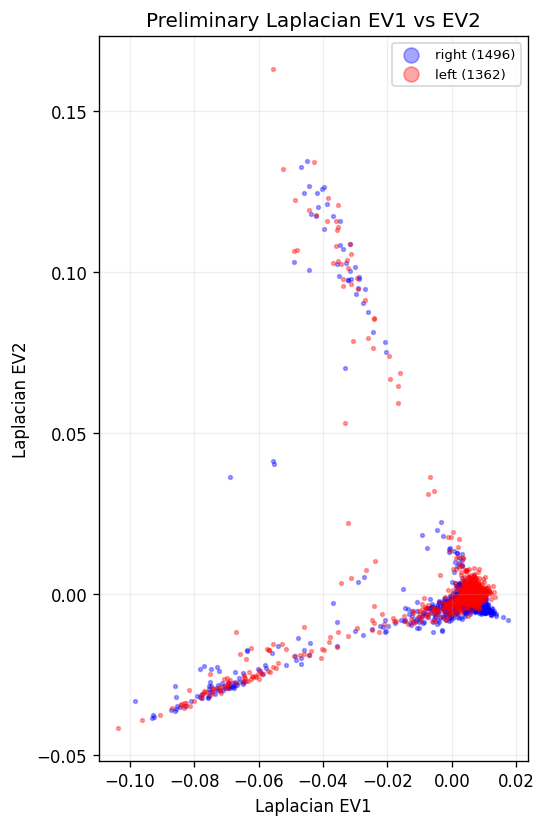

In [6]:
# ============================================================
# Scatterplot of selected EV pair, colored by viewpoint
# ============================================================

vp_colors_map = {'right': 'blue', 'left': 'red', 'front': 'green', 'back': 'orange'}
vp_order = ['right', 'left', 'back', 'front']

fig, ax = plt.subplots(figsize=(7, 7))
for vp in vp_order:
    m = valid_vps == vp
    if m.any():
        ax.scatter(
            eigenvectors[m, EV_X], eigenvectors[m, EV_Y],
            c=vp_colors_map.get(vp, 'gray'), s=5, alpha=0.35, label=f'{vp} ({m.sum()})',
        )
ax.set_xlabel(f'Laplacian EV{EV_X}')
ax.set_ylabel(f'Laplacian EV{EV_Y}')
ax.set_title(f'Preliminary Laplacian EV{EV_X} vs EV{EV_Y}')
ax.legend(markerscale=4, fontsize=8)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Interactive threshold controls and preview
# ============================================================

def _ev_bounds(ev_idx):
    vals = eigenvectors[:, ev_idx]
    return float(vals.min()), float(vals.max())

ev_x_widget = widgets.IntSlider(value=EV_X, min=1, max=N_EIG - 1, step=1, description='EV X')
ev_y_widget = widgets.IntSlider(value=EV_Y, min=1, max=N_EIG - 1, step=1, description='EV Y')
x_min_widget = widgets.FloatText(value=_ev_bounds(EV_X)[0], description='X min')
x_max_widget = widgets.FloatText(value=_ev_bounds(EV_X)[1], description='X max')
y_min_widget = widgets.FloatText(value=_ev_bounds(EV_Y)[0], description='Y min')
y_max_widget = widgets.FloatText(value=_ev_bounds(EV_Y)[1], description='Y max')

current_keep_mask = np.ones(len(valid_dets), dtype=bool)
current_rule_text = ''

def _update_bounds(*_):
    x_min_widget.value, x_max_widget.value = _ev_bounds(ev_x_widget.value)
    y_min_widget.value, y_max_widget.value = _ev_bounds(ev_y_widget.value)

ev_x_widget.observe(_update_bounds, names='value')
ev_y_widget.observe(_update_bounds, names='value')

def preview_filter(ev_x, ev_y, x_min, x_max, y_min, y_max):
    global current_keep_mask, current_rule_text
    x = eigenvectors[:, ev_x]
    y = eigenvectors[:, ev_y]
    keep = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    current_keep_mask = keep
    current_rule_text = (
        f'EV{ev_x} >= {x_min:.8g} and EV{ev_x} <= {x_max:.8g} and '
        f'EV{ev_y} >= {y_min:.8g} and EV{ev_y} <= {y_max:.8g}'
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    ax.scatter(x[~keep], y[~keep], c='lightgray', s=5, alpha=0.3, label=f'dropped ({(~keep).sum()})')
    for vp in vp_order:
        m = keep & (valid_vps == vp)
        if m.any():
            ax.scatter(x[m], y[m], c=vp_colors_map.get(vp, 'gray'), s=6, alpha=0.55, label=f'{vp} ({m.sum()})')
    ax.axvline(x_min, color='black', lw=1, ls='--')
    ax.axvline(x_max, color='black', lw=1, ls='--')
    ax.axhline(y_min, color='black', lw=1, ls='--')
    ax.axhline(y_max, color='black', lw=1, ls='--')
    ax.set_xlabel(f'EV{ev_x}')
    ax.set_ylabel(f'EV{ev_y}')
    ax.set_title(f'Kept {keep.sum()} / {len(keep)} detections')
    ax.legend(markerscale=3, fontsize=8)
    ax.set_aspect('equal', adjustable='box')

    kept_counts = Counter(valid_vps[keep])
    dropped_counts = Counter(valid_vps[~keep])
    labels = sorted(set(valid_vps))
    xs = np.arange(len(labels))
    axes[1].bar(xs - 0.2, [kept_counts[v] for v in labels], width=0.4, label='kept')
    axes[1].bar(xs + 0.2, [dropped_counts[v] for v in labels], width=0.4, label='dropped')
    axes[1].set_xticks(xs)
    axes[1].set_xticklabels(labels, rotation=30, ha='right')
    axes[1].set_ylabel('detections')
    axes[1].set_title('Viewpoint breakdown')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print(current_rule_text)

ui = widgets.VBox([
    widgets.HBox([ev_x_widget, ev_y_widget]),
    widgets.HBox([x_min_widget, x_max_widget]),
    widgets.HBox([y_min_widget, y_max_widget]),
])
out = widgets.interactive_output(
    preview_filter,
    {
        'ev_x': ev_x_widget,
        'ev_y': ev_y_widget,
        'x_min': x_min_widget,
        'x_max': x_max_widget,
        'y_min': y_min_widget,
        'y_max': y_max_widget,
    },
)
display(ui, out)

Output()

In [10]:
# ============================================================
# Save the currently previewed filter as a minimal JSON artifact
# ============================================================

filtered_det_ids = [d for d, keep in zip(valid_dets, current_keep_mask) if keep]
artifact_path = config.output_root / 'viewpoint_filters' / f'{FILTER_NAME}.json'
saved_path = save_viewpoint_filter(
    artifact_path,
    filter_name=FILTER_NAME,
    filtered_det_ids=filtered_det_ids,
    source_det_ids=valid_dets,
    rule_text=current_rule_text,
    params={
        'config_path': str(CONFIG_PATH),
        'knn_k': KNN_K,
        'n_eig': N_EIG,
        'ev_indices_used': [int(ev_x_widget.value), int(ev_y_widget.value)],
        'fv_components': {
            'use_weight': USE_WEIGHT,
            'use_mean': USE_MEAN,
            'use_var': USE_VAR,
            'max_pca_dim': MAX_PCA_DIM,
        },
    },
)
print(f'Saved {len(filtered_det_ids)} / {len(valid_dets)} detections to {saved_path}')

Saved 2775 / 2858 detections to /scratch/project_2001382/alex/semantic-matching-output/seal/viewpoint_filters/hands_filter.json
